# DINO: Aprendizaje Auto-Supervisado para Vision

DINOv2 y DINOv3 son modelos que aprenden features visuales sin necesidad de etiquetas. Aprenden mirando millones de imagenes y encontrando patrones por si mismos.

**Para que sirve:**
- Extraer features (embeddings) de imagenes
- Encontrar similitudes entre imagenes o regiones
- Servir como base (backbone) para otros modelos
- Clustering y busqueda de imagenes similares

La ventaja: no necesita datos etiquetados, aprende conceptos generales de manera automatica.

## Configuracion e Imports

In [1]:
import torch
import transformers
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import cv2
import requests
from io import BytesIO
import warnings
import torch.nn.functional as F
warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch version: {torch.__version__}, usando: {device}")
print(f"transformers version: {transformers.__version__}")

torch version: 2.7.1+cu128, usando: cuda
transformers version: 4.57.1


## Carga del Modelo DINOv2

Usamos `facebook/dinov2-base` que es la version de tamaño medio. Hay versiones small, base, large y giant segun necesites mas precision o velocidad.

In [2]:
# model_name = "facebook/dinov2-base" #DINOV2
model_name = "facebook/dinov3-vitb16-pretrain-lvd1689m" #DINOv3

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

print(f"Modelo DINO cargado: {model_name}")
print(f"Dimension de embeddings: {model.config.hidden_size}")

Modelo DINO cargado: facebook/dinov3-vitb16-pretrain-lvd1689m
Dimension de embeddings: 768


## Carga de Imagenes de Ejemplo

In [3]:
# Cargar imagenes desde GitHub
url_cars = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/cars.jpg"
image_cars = Image.open(BytesIO(requests.get(url_cars).content)).convert("RGB")

url_person_cars = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/person_cars.jpg"
image_person_cars = Image.open(BytesIO(requests.get(url_person_cars).content)).convert("RGB")

url_person_dog = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/person_dog2.jpg"
image_person_dog = Image.open(BytesIO(requests.get(url_person_dog).content)).convert("RGB")

url_dog = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/dog.jpg"
image_dog = Image.open(BytesIO(requests.get(url_dog).content)).convert("RGB")

url_fruits = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/fruits.jpg"
image_fruits = Image.open(BytesIO(requests.get(url_fruits).content)).convert("RGB")

url_bananas = "https://github.com/sergiovillanueva/modelos_fundacionales/raw/main/assets/bananas.jpg"
image_bananas = Image.open(BytesIO(requests.get(url_bananas).content)).convert("RGB")
print("Imagenes cargadas")

Imagenes cargadas


## Extraer Embeddings de una Imagen

DINOv2 genera un embedding (vector numerico) que representa el contenido de la imagen. Imagenes similares tendran embeddings similares.

El modelo divide la imagen en patches (trozos) y genera un embedding para cada uno, mas un token especial `[CLS]` que representa la imagen completa.

In [4]:
def extract_embeddings(image, resize=False):
    """Extrae embeddings de imagen usando DINOv2/v3"""    
    inputs = processor(images=image, return_tensors="pt", do_resize=resize).to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # CLS token: representa la imagen completa
    cls_embedding = outputs.last_hidden_state[0, 0, :].cpu().numpy()
    
    # Patch tokens: cada region de la imagen
    patch_embeddings = outputs.last_hidden_state[0, 1:, :].cpu().numpy()
    
    print(f"Embedding global (CLS): {cls_embedding.shape}, Patch embeddings: {patch_embeddings.shape}")
    
    return cls_embedding, patch_embeddings

cls_emb, patch_emb = extract_embeddings(image_cars)

Embedding global (CLS): (768,), Patch embeddings: (2254, 768)


## Similitud entre Imagenes

Podemos calcular la similitud entre dos imagenes usando sus embeddings. La similitud coseno nos dice que tan parecidas son (1 = identicas, 0 = no relacionadas).

Embedding global (CLS): (768,), Patch embeddings: (3140, 768)
Embedding global (CLS): (768,), Patch embeddings: (3140, 768)

Similitud entre im1 y im2: -0.128


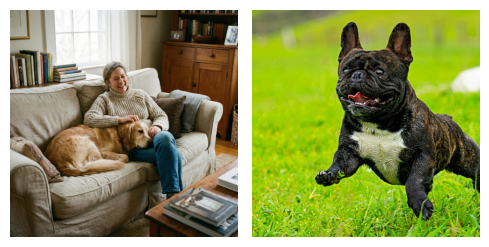

In [5]:
def compare_images(img1, img2):
    """Calcula similitud coseno entre los embeddings de las imagenes"""
    # Extraemos los embeddings con la función de antes
    cls_1, _ = extract_embeddings(img1)
    cls_2, _ = extract_embeddings(img2)

    # Aplanamos los embeddings y calculamos la similitud coseno
    emb1 = cls_1.flatten()
    emb2 = cls_2.flatten()
    similarity = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
    
    print(f"\nSimilitud entre im1 y im2: {similarity:.3f}")
    
    # Visualizar
    fig, axes = plt.subplots(1, 2, figsize=(5, 5))
    axes[0].imshow(img1)
    axes[0].axis("off")
    axes[1].imshow(img2)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()
    return similarity

    
# compare_images(image_cars, image_dog)
compare_images(image_person_dog, image_dog);



Embedding global (CLS): (768,), Patch embeddings: (3140, 768)


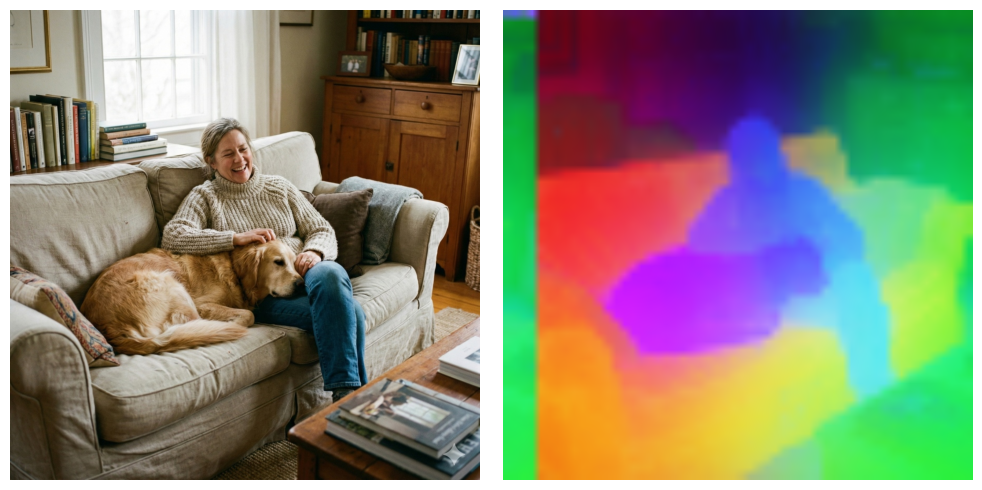

In [19]:
def visualize_embeddings(img):
    """Visualiza los embeddings de parches con colores vibrantes usando PCA + sigmoid"""
    _, patch_emb = extract_embeddings(img, False)

    pixel_values = processor(images=img, return_tensors="pt", do_resize=False)["pixel_values"]
    patch_size = model.config.patch_size
    tokens_h = pixel_values.shape[-2] // patch_size
    tokens_w = pixel_values.shape[-1] // patch_size
    tokens_hw = tokens_h * tokens_w

    # PCA y transformación sigmoid para colores vibrantes
    pca = PCA(n_components=3, whiten=True)
    pca_features = pca.fit_transform(patch_emb[:tokens_hw])
    pca_tensor = torch.from_numpy(pca_features).view(tokens_h, tokens_w, 3)
    img_pca_2d = torch.nn.functional.sigmoid(pca_tensor.mul(2.0)).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img)
    axes[0].axis("off")
    axes[1].imshow(img_pca_2d, interpolation="bilinear")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()


visualize_embeddings(image_person_dog)

Embedding global (CLS): (768,), Patch embeddings: (3140, 768)
Embedding global (CLS): (768,), Patch embeddings: (3140, 768)


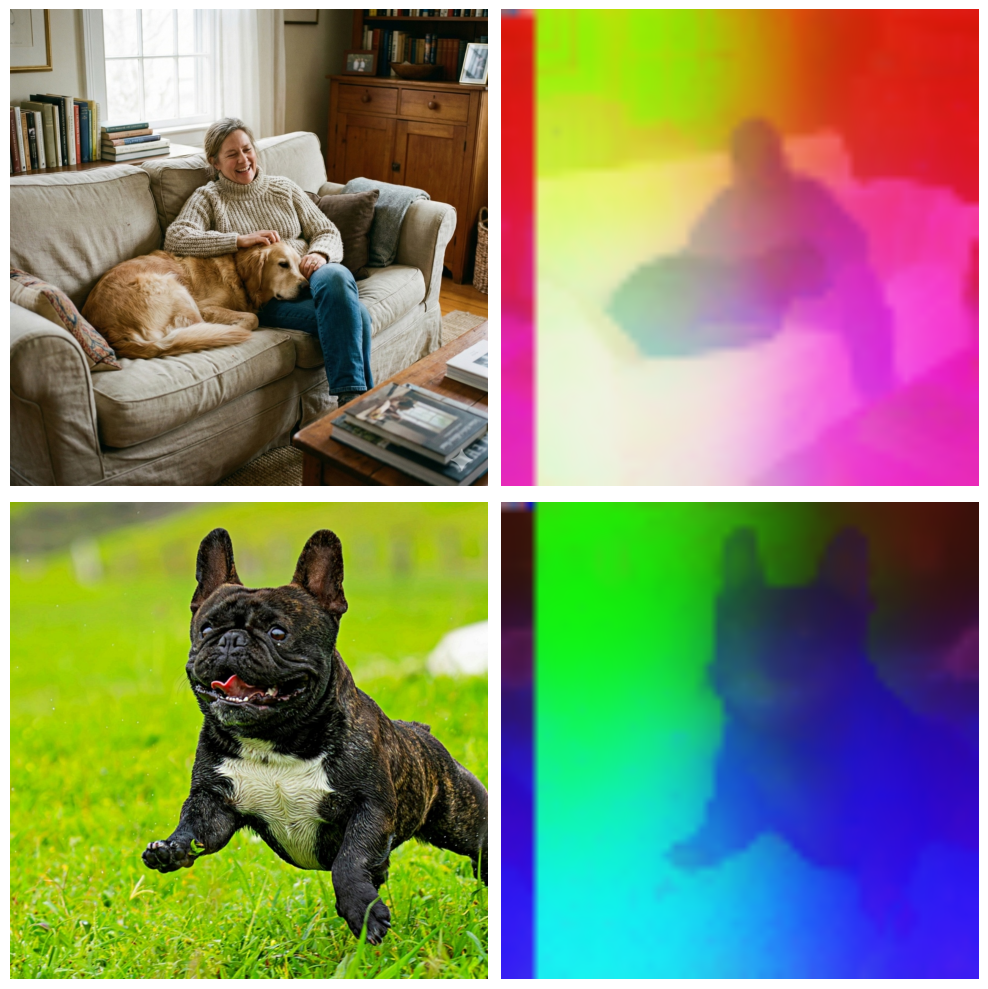

In [21]:
def visualize_embeddings_together(img1, img2):
    """Visualiza los embeddings de 2 imagenes en el mismo espacio PCA con colores vibrantes"""
    _, patch_emb_1 = extract_embeddings(img1, False)
    _, patch_emb_2 = extract_embeddings(img2, False)
    
    # Calcular dimensiones de cada imagen
    pixel_values_1 = processor(images=img1, return_tensors="pt", do_resize=False)["pixel_values"]
    pixel_values_2 = processor(images=img2, return_tensors="pt", do_resize=False)["pixel_values"]
    patch_size = model.config.patch_size
    
    tokens_h1 = pixel_values_1.shape[-2] // patch_size
    tokens_w1 = pixel_values_1.shape[-1] // patch_size
    tokens_hw1 = tokens_h1 * tokens_w1
    
    tokens_h2 = pixel_values_2.shape[-2] // patch_size
    tokens_w2 = pixel_values_2.shape[-1] // patch_size
    tokens_hw2 = tokens_h2 * tokens_w2
    
    # Combinar embeddings en el mismo espacio PCA
    combined = np.vstack([patch_emb_1[:tokens_hw1], patch_emb_2[:tokens_hw2]])
    
    # PCA en el espacio combinado
    pca = PCA(n_components=3, whiten=True)
    pca_features = pca.fit_transform(combined)
    
    # Separar las features y aplicar sigmoid
    pca_img1 = torch.from_numpy(pca_features[:tokens_hw1]).view(tokens_h1, tokens_w1, 3)
    pca_img2 = torch.from_numpy(pca_features[tokens_hw1:]).view(tokens_h2, tokens_w2, 3)
    
    img_pca_1 = torch.nn.functional.sigmoid(pca_img1.mul(2.0)).numpy()
    img_pca_2 = torch.nn.functional.sigmoid(pca_img2.mul(2.0)).numpy()
    
    # Visualizar
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes[0, 0].imshow(img1)
    axes[0, 0].axis("off")
    axes[0, 1].imshow(img_pca_1, interpolation="bilinear")
    axes[0, 1].axis("off")
    axes[1, 0].imshow(img2)
    axes[1, 0].axis("off")
    axes[1, 1].imshow(img_pca_2, interpolation="bilinear")
    axes[1, 1].axis("off")
    plt.tight_layout()
    plt.show()
    
visualize_embeddings_together(image_person_dog, image_dog)

Embedding global (CLS): (768,), Patch embeddings: (256, 768)


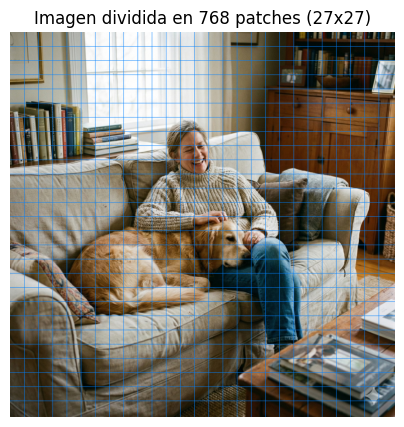

In [10]:
def extract_and_show_grid(image):
    """Extrae embeddings y muestra la cuadrícula de patches"""
    
    cls_emb, patch_emb = extract_embeddings(image)
    
    # Calcular el tamaño del grid
    num_patches = patch_emb.shape[1]
    grid_size = int(np.sqrt(num_patches))
    
    # Convertir imagen a array numpy
    img_array = np.array(image)
    h, w = img_array.shape[:2]
    
    # Tamaño de cada patch
    patch_h = h // grid_size
    patch_w = w // grid_size
    
    # Crear copia para dibujar
    img_with_grid = img_array.copy()
    
    # Dibujar líneas del grid
    for i in range(1, grid_size):
        # Líneas horizontales
        cv2.line(img_with_grid, (0, i * patch_h), (w, i * patch_h), (0, 128, 255), 1)
        # Líneas verticales
        cv2.line(img_with_grid, (i * patch_w, 0), (i * patch_w, h), (0, 128, 255), 1)
    
    plt.figure(figsize=(5, 5))
    plt.imshow(img_with_grid)
    plt.title(f"Imagen dividida en {num_patches} patches ({grid_size}x{grid_size})")
    plt.axis("off")
    plt.show()
    
    
extract_and_show_grid(image_person_dog)

## Visualizacion de Patches con t-SNE

t-SNE es una tecnica para visualizar datos de alta dimension (como los embeddings de 768 dimensiones) en 2D. Patches similares aparecen cerca en el grafico.

Esto nos ayuda a entender que regiones de la imagen son similares entre si.

In [ ]:
def visualize_patches_tsne(image):
    """Visualiza patches de imagen usando t-SNE"""
    
    _, patch_emb = extract_embeddings(image)
    patch_emb = patch_emb[0]  # Quitar dimension de batch
    
    # Reducir dimension con PCA primero (mas rapido)
    pca = PCA(n_components=50)
    patch_emb_pca = pca.fit_transform(patch_emb)
    
    # Aplicar t-SNE para proyectar a 2D
    print("Calculando t-SNE... (puede tardar un poco)")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    patch_emb_2d = tsne.fit_transform(patch_emb_pca)
    
    # Calcular grid de patches (DINOv2 usa patches de 14x14)
    num_patches = patch_emb.shape[0]
    grid_size = int(np.sqrt(num_patches))
    
    # Visualizar
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Imagen original
    axes[0].imshow(image)
    axes[0].set_title("Imagen Original")
    axes[0].axis("off")
    
    # t-SNE projection
    scatter = axes[1].scatter(patch_emb_2d[:, 0], patch_emb_2d[:, 1], 
                            c=range(num_patches), cmap='viridis', s=50)
    axes[1].set_title(f"t-SNE de {num_patches} patches")
    axes[1].set_xlabel("t-SNE dimension 1")
    axes[1].set_ylabel("t-SNE dimension 2")
    plt.colorbar(scatter, ax=axes[1], label="Patch ID")
    
    plt.tight_layout()
    plt.show()
    
    return patch_emb_2d

# Visualizar patches de coches
tsne_result = visualize_patches_tsne(image_cars)

## Mapa de Similitud entre Regiones

Podemos seleccionar un patch especifico y ver que otros patches son similares a el. Esto es util para encontrar regiones relacionadas en la imagen.

In [ ]:
def similarity_map(image, reference_patch_idx=None):
    """Muestra mapa de similitud respecto a un patch de referencia"""
    
    _, patch_emb = extract_embeddings(image)
    patch_emb = patch_emb[0]  # Quitar dimension de batch
    
    num_patches = patch_emb.shape[0]
    grid_size = int(np.sqrt(num_patches))
    
    # Patch de referencia (por defecto el centro)
    if reference_patch_idx is None:
        reference_patch_idx = num_patches // 2
    
    ref_patch = patch_emb[reference_patch_idx]
    
    # Calcular similitud con todos los patches
    similarities = []
    for i in range(num_patches):
        sim = cosine_similarity(ref_patch, patch_emb[i])
        similarities.append(sim)
    
    similarities = np.array(similarities)
    
    # Reshape a grid
    sim_grid = similarities.reshape(grid_size, grid_size)
    
    # Visualizar
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].imshow(image)
    axes[0].set_title("Imagen Original")
    axes[0].axis("off")
    
    im = axes[1].imshow(sim_grid, cmap='hot', interpolation='nearest')
    axes[1].set_title(f"Similitud con patch {reference_patch_idx}")
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], label="Similitud")
    
    plt.tight_layout()
    plt.show()
    
    return sim_grid

# Calcular mapa de similitud
sim_map = similarity_map(image_cars)

## Aplicacion: Encontrar Regiones Similares

Podemos usar DINOv2 para encontrar regiones similares en imagenes industriales, por ejemplo:
- Encontrar defectos similares en piezas
- Agrupar componentes parecidos
- Buscar patrones repetidos

In [ ]:
def find_similar_regions(image, top_k=5):
    """Encuentra las k regiones mas similares en la imagen"""
    
    _, patch_emb = extract_embeddings(image)
    patch_emb = patch_emb[0]
    
    num_patches = patch_emb.shape[0]
    grid_size = int(np.sqrt(num_patches))
    
    # Calcular similitud promedio de cada patch con todos los demas
    avg_similarities = []
    for i in range(num_patches):
        sims = [cosine_similarity(patch_emb[i], patch_emb[j]) for j in range(num_patches) if i != j]
        avg_similarities.append(np.mean(sims))
    
    # Encontrar patches mas representativos
    top_indices = np.argsort(avg_similarities)[-top_k:]
    
    print(f"Top {top_k} patches mas representativos:")
    for idx in top_indices:
        print(f"  Patch {idx}: similitud promedio = {avg_similarities[idx]:.4f}")
    
    # Visualizar patches en grid
    highlight_grid = np.zeros((grid_size, grid_size))
    for idx in top_indices:
        row = idx // grid_size
        col = idx % grid_size
        highlight_grid[row, col] = 1
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].imshow(image)
    axes[0].set_title("Imagen Original")
    axes[0].axis("off")
    
    axes[1].imshow(highlight_grid, cmap='Reds', interpolation='nearest')
    axes[1].set_title("Regiones mas representativas")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()

find_similar_regions(image_cars, top_k=10)

In [ ]:
# !pip install python-dotenv huggingface_hub

# # colab
# import os
# os.environ["HF_TOKEN"] = input("Introduce tu token HF: ")

# from huggingface_hub import login
# login(token=os.environ["HF_TOKEN"])


# En el código
from dotenv import load_dotenv
import os
from huggingface_hub import login

# load_dotenv()  # Lee el archivo .env
# login(token=os.getenv("HF_TOKEN"))
# print("Login successful!")


# from transformers import AutoImageProcessor, AutoModel
# from transformers.image_utils import load_image


# url = "http://images.cocodataset.org/val2017/000000039769.jpg"
# image = load_image(url)

# pretrained_model_name = "facebook/dinov3-vitl16-pretrain-lvd1689m"
# processor = AutoImageProcessor.from_pretrained(pretrained_model_name, token=os.getenv("HF_TOKEN"))
# model = AutoModel.from_pretrained(
#     pretrained_model_name, 
#     device_map="auto",
#     token=os.getenv("HF_TOKEN")
# )

# inputs = processor(images=image, return_tensors="pt").to(model.device)
# with torch.inference_mode():
#     outputs = model(**inputs)

# pooled_output = outputs.pooler_output
# print("Pooled output shape:", pooled_output.shape)


## Ejercicio: Compara dos imagenes diferentes

Usa las funciones que hemos creado para:
1. Extraer embeddings de `image_cars` e `image_fruits`
2. Calcular la similitud entre ellas
3. Visualizar los mapas de similitud de cada una

In [ ]:
# EJERCICIO: Tu codigo aqui

# Paso 1: Extraer embeddings
# ...

# Paso 2: Calcular similitud
# ...

# Paso 3: Visualizar mapas
# ...


## Ejercicio Extra (Comodin): Clustering de Patches

Usa K-Means para agrupar los patches en clusters y visualiza que partes de la imagen pertenecen a cada grupo.

**Pista**: Usa `sklearn.cluster.KMeans` sobre los embeddings de patches.

In [ ]:
# EJERCICIO EXTRA: Clustering de patches
from sklearn.cluster import KMeans

def cluster_patches(image, n_clusters=5):
    """Agrupa patches en clusters usando K-Means"""
    # Tu codigo aqui...
    pass

# Prueba:
# cluster_patches(image_cars, n_clusters=5)


## Resumen

En este notebook hemos aprendido:

✅ Que es el aprendizaje auto-supervisado  
✅ Como funciona DINOv2 como extractor de features  
✅ Extraer embeddings globales y por patches  
✅ Calcular similitud entre imagenes y regiones  
✅ Visualizar embeddings con t-SNE  
✅ Crear mapas de similitud  
✅ Aplicaciones en vision industrial  

**Siguiente paso**: En el proximo notebook veremos SAM2 para segmentacion universal y como combinarlo con Grounding DINO y Qwen2.5-VL.

**Contacto**: Si tienes dudas puedes escribirme un email!